# Final analysis and career recommendations
**Group 4 | BU MET AD688 | Data Analyst careers in NAICS 523**

Turn the market evidence, team skill assessment and salary model into four decisions: what to learn, which experience level to target, how to benchmark salary, and where to search. This is a selected historical sample, not a live job-search service.


## 1. Load the data and main model results


In [1]:
from pathlib import Path
import json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display, Markdown

# Run this notebook from the project folder.
PROJECT = Path.cwd()
if not (PROJECT / "data/career_market_panel.csv").exists():
    PROJECT = PROJECT.parent

DATA_FILE = PROJECT / "data/career_market_panel.csv"
FIGURES = PROJECT / "figures"
RESULTS = PROJECT / "output/regression"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180})
print("Data shape:", df.shape)
print("Posting dates:", df["POSTED"].min(), "to", df["POSTED"].max())
df.head(3)

import hashlib
summary_file = RESULTS / "ml_analysis_summary.json"
if not summary_file.exists():
    raise FileNotFoundError("Run ml_methods.ipynb before this notebook.")
ml_summary = json.loads(summary_file.read_text())
if hashlib.sha256(DATA_FILE.read_bytes()).hexdigest() != ml_summary["source_sha256"]:
    raise ValueError("The data changed. Rerun ml_methods.ipynb first.")
metrics = pd.DataFrame(ml_summary["metrics"])


Data shape: (140, 42)
Posting dates: 2024-05-02 to 2024-09-30


## 2. Prepare the same fields
Use the same cleaning, JSON skill lists and profile grouping as the ML notebook. A skill indicator means the posting mentions a skill, not that an applicant has mastered it. SQL is used for the summaries below.


In [2]:
# Convert numeric fields. Missing experience stays missing for now.
number_cols = ["salary_midpoint", "SALARY_FROM", "SALARY_TO", "MIN_YEARS_EXPERIENCE"]
for col in number_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.loc[df["MIN_YEARS_EXPERIENCE"] < 0, "MIN_YEARS_EXPERIENCE"] = np.nan

# Use the cleaned location and remote fields instead of their raw duplicates.
for col in ["remote_status", "city_clean", "state_clean"]:
    df[col] = df[col].fillna("Unknown").str.strip().replace("", "Unknown")
# Original pay period is metadata; the salary amounts were already annualized.
df["pay_period"] = df["ORIGINAL_PAY_PERIOD"].fillna("Unknown").str.lower().str.strip()

print("Duplicate IDs:", df["ID"].duplicated().sum())
df = df.drop_duplicates("ID").copy()
print("Missing salary:", df["salary_midpoint"].isna().sum())
print("Missing minimum experience:", df["MIN_YEARS_EXPERIENCE"].isna().sum())


Duplicate IDs: 0
Missing salary: 54
Missing minimum experience: 28


In [3]:
# This follows the JSON-list parsing in skill_gap_analysis.ipynb.
skill_cols = ["SKILLS_NAME", "SPECIALIZED_SKILLS_NAME", "COMMON_SKILLS_NAME", "SOFTWARE_SKILLS_NAME"]

def parse_skill_list(value):
    if pd.isna(value):
        return []
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except (json.JSONDecodeError, TypeError):
        return []

for col in skill_cols:
    df[col + "_parsed"] = df[col].apply(parse_skill_list)

# Combine the four lists; a skill is counted once per posting.
df["all_skills"] = df.apply(
    lambda row: sorted(set(skill for col in skill_cols for skill in row[col + "_parsed"])),
    axis=1
)


In [4]:
# Eight skill groups selected from the existing skill-gap analysis.
# A value of 1 means the skill is mentioned, not that a person has mastered it.
skill_map = {
    "has_sql": ["SQL (Programming Language)"],
    "has_python": ["Python (Programming Language)"],
    "has_excel": ["Microsoft Excel"],
    "has_bi": ["Power BI", "Tableau (Business Intelligence Software)"],
    "has_statistics": ["Statistics"],
    "has_visualization": ["Data Visualization"],
    "has_ml": ["Machine Learning"],
    "has_aws": ["Amazon Web Services"]
}
skill_labels = {
    "has_sql": "SQL", "has_python": "Python", "has_excel": "Excel",
    "has_bi": "Power BI / Tableau", "has_statistics": "Statistics",
    "has_visualization": "Data Visualization", "has_ml": "Machine Learning",
    "has_aws": "AWS / Cloud"
}
for feature, names in skill_map.items():
    df[feature] = df["all_skills"].apply(lambda skills: int(any(name in skills for name in names)))
df["experience_missing"] = df["MIN_YEARS_EXPERIENCE"].isna().astype(int)


In [5]:
# Same employer + cleaned title + normalized description = one posting profile.
# Salary is deliberately NOT used to create the groups.
body_clean = df["BODY"].fillna("").str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
profile_key = (
    df["COMPANY_NAME"].fillna("Unknown").str.lower().str.strip() + " | "
    + df["TITLE_CLEAN"].fillna("").str.lower().str.strip() + " | " + body_clean
)
# Missing descriptions cannot establish that two postings are the same profile.
profile_key = profile_key.where(body_clean.ne(""), "missing body | " + df["ID"].astype(str))
df["profile_id"] = pd.factorize(profile_key)[0]
profile_counts = df.groupby("profile_id").size().sort_values(ascending=False)
print("Postings:", len(df), "| Distinct posting profiles:", df["profile_id"].nunique())
print("Largest repeated profile:", profile_counts.iloc[0], "postings")
# SQLite is included with Python. Use SQL for filters, joins, counts and summaries.
connection = sqlite3.connect(":memory:")
sql_cols = [
    "ID", "COMPANY_NAME", "TITLE_RAW", "TITLE_CLEAN", "POSTED", "profile_id",
    "salary_midpoint", "SALARY_FROM", "SALARY_TO", "MIN_YEARS_EXPERIENCE",
    "remote_status", "city_clean", "state_clean", "pay_period",
    "industry_scope", "career_scope", "experience_missing"
] + list(skill_map)
df[sql_cols].to_sql("jobs", connection, index=False, if_exists="replace")




Postings: 140 | Distinct posting profiles: 102
Largest repeated profile: 38 postings


140

## 3. Read the sample and salary benchmark
Repeated descriptions are counted once for the profile benchmark. The salary midpoint is the average of the already annualized endpoints. It is not an individual offer or an entry-level salary range.


In [6]:
sample_summary = pd.read_sql_query("""
    SELECT COUNT(*) AS total_postings,
           COUNT(DISTINCT profile_id) AS distinct_profiles,
           COUNT(salary_midpoint) AS salary_records,
           SUM(CASE WHEN salary_midpoint > 0 AND SALARY_FROM > 0 AND SALARY_TO >= SALARY_FROM
                     AND ABS(salary_midpoint - (SALARY_FROM + SALARY_TO) / 2.0) < 0.01 THEN 1 ELSE 0 END) AS model_salary_postings,
           COUNT(DISTINCT CASE WHEN salary_midpoint > 0 AND SALARY_FROM > 0 AND SALARY_TO >= SALARY_FROM
                     AND ABS(salary_midpoint - (SALARY_FROM + SALARY_TO) / 2.0) < 0.01 THEN profile_id END) AS model_salary_profiles,
           SUM(CASE WHEN MIN_YEARS_EXPERIENCE IS NULL THEN 1 ELSE 0 END) AS missing_experience,
           SUM(CASE WHEN remote_status = 'Unknown' THEN 1 ELSE 0 END) AS unknown_remote
    FROM jobs
""", connection)
display(sample_summary.T.rename(columns={0: "Count"}))


annual_salary = pd.read_sql_query("""
    SELECT * FROM jobs
    WHERE salary_midpoint > 0
      AND SALARY_FROM > 0 AND SALARY_TO >= SALARY_FROM
      AND ABS(salary_midpoint - (SALARY_FROM + SALARY_TO) / 2.0) < 0.01
""", connection)
annual_profiles = annual_salary.drop_duplicates("profile_id").copy()
benchmark_rows = []
for label, values in [
    ("Usable annualized salary postings", annual_salary["salary_midpoint"]),
    ("Distinct annualized salary profiles", annual_profiles["salary_midpoint"])
]:
    benchmark_rows.append({
        "Sample": label, "N": len(values), "Mean_USD": values.mean(),
        "Median_USD": values.median(), "P25_USD": values.quantile(0.25), "P75_USD": values.quantile(0.75)
    })
salary_benchmarks = pd.DataFrame(benchmark_rows)
display(salary_benchmarks.round(0))


,Count
total_postings,140
distinct_profiles,102
salary_records,86
model_salary_postings,86
model_salary_profiles,48
missing_experience,28
unknown_remote,71


,Sample,N,Mean_USD,Median_USD,P25_USD,P75_USD
0,Usable annualized salary postings,86,90861.0,93850.0,90120.0,93850.0
1,Distinct annualized salary profiles,48,89230.0,92296.0,71875.0,100038.0


In [7]:
profile_benchmark = salary_benchmarks.iloc[-1]
display(Markdown(
    f"**Salary benchmark:** the median across {int(profile_benchmark['N'])} distinct annualized salary profiles "
    f"is ${profile_benchmark['Median_USD']:,.0f}. The middle 50% spans "
    f"${profile_benchmark['P25_USD']:,.0f}–${profile_benchmark['P75_USD']:,.0f}. "
    "This interquartile range describes the sample; it is not a predicted offer range or confidence interval."
))


**Salary benchmark:** the median across 48 distinct annualized salary profiles is $92,296. The middle 50% spans $71,875–$100,038. This interquartile range describes the sample; it is not a predicted offer range or confidence interval.

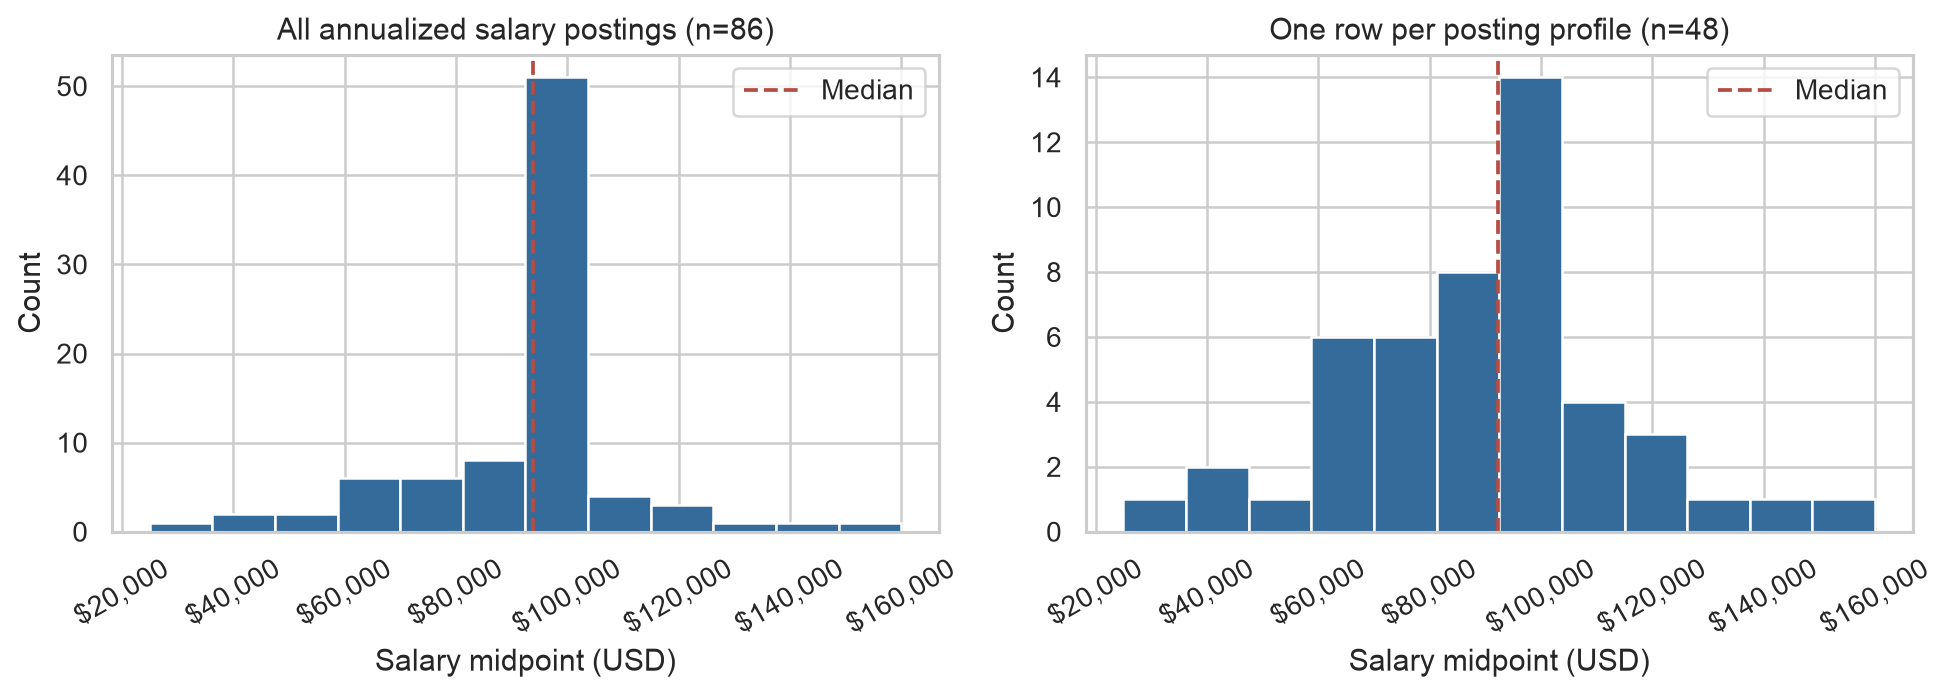

In [8]:
from IPython.display import Image
display(Image(filename=str(FIGURES / "ml_salary_distribution.png")))


## 4. Prioritize skills and demonstrate them
Compare employer demand across 102 profiles with the team's existing 1–5 self-assessment. The combined BI group includes Power BI or Tableau. The original skill-gap notebook also covers communication and business-analysis strengths.


In [9]:
skill_rows = []
for _, row in df.iterrows():
    for feature in skill_map:
        skill_rows.append({
            "ID": row["ID"], "profile_id": row["profile_id"],
            "Skill": skill_labels[feature], "Mentioned": row[feature]
        })
skill_long = pd.DataFrame(skill_rows)
skill_long.to_sql("skill_flags", connection, index=False, if_exists="replace")

skill_demand = pd.read_sql_query("""
    SELECT Skill, SUM(Mentioned) AS Posting_Count,
           COUNT(DISTINCT CASE WHEN Mentioned = 1 THEN profile_id END) AS Profile_Count,
           ROUND(100.0 * SUM(Mentioned) / COUNT(*), 1) AS Posting_Demand_Percent,
           ROUND(100.0 * COUNT(DISTINCT CASE WHEN Mentioned = 1 THEN profile_id END)
                 / COUNT(DISTINCT profile_id), 1) AS Profile_Demand_Percent
    FROM skill_flags
    GROUP BY Skill
    ORDER BY Profile_Demand_Percent DESC
""", connection)

plot_demand = skill_demand.sort_values("Profile_Demand_Percent")
positions = np.arange(len(plot_demand))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(positions - 0.18, plot_demand["Posting_Demand_Percent"], height=0.35, color="#346b9a", label="Posting demand")
ax.barh(positions + 0.18, plot_demand["Profile_Demand_Percent"], height=0.35, color="#67a28c", label="Distinct-profile demand")
ax.set_yticks(positions, plot_demand["Skill"])
ax.set(title="Skill demand: sensitivity to repeated descriptions", xlabel="Mentioned in sample (%)", xlim=(0, 100))
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "final_skill_demand.png", bbox_inches="tight")
plt.show()


<Figure size 990x550 with 1 Axes>

In [10]:
team_skills = pd.DataFrame({
    "Skill": ["Python", "SQL", "Power BI / Tableau"],
    "Taiqi": [3, 3, 4], "Joseph": [2, 2, 3], "Igor": [2, 2, 3]
})
team_long = team_skills.melt(id_vars="Skill", var_name="Member", value_name="Proficiency")
team_long.to_sql("team_proficiency", connection, index=False, if_exists="replace")
skill_demand.to_sql("skill_demand", connection, index=False, if_exists="replace")
priorities = pd.read_sql_query("""
    SELECT t.Member, t.Skill, t.Proficiency, d.Profile_Demand_Percent,
           CASE WHEN d.Profile_Demand_Percent >= 35 AND t.Proficiency <= 3 THEN 'High'
                ELSE 'Medium' END AS Priority
    FROM team_proficiency t JOIN skill_demand d ON t.Skill = d.Skill
    ORDER BY t.Member, d.Profile_Demand_Percent DESC
""", connection)
display(priorities.pivot(index="Skill", columns="Member", values="Priority"))

learning_plan = pd.DataFrame({
    "Skill": ["SQL", "Python", "Power BI / Tableau"],
    "Portfolio evidence": [
        "Use joins, aggregation and window functions to answer business questions.",
        "Clean and analyze data in a reproducible notebook; explain the findings.",
        "Build a dashboard with clear business measures and a decision-focused summary."
    ]
})
display(learning_plan)


Member,Igor,Joseph,Taiqi
Skill,,,
Power BI / Tableau,High,High,Medium
Python,High,High,High
SQL,High,High,High


,Skill,Portfolio evidence
0,SQL,"Use joins, aggregation and window functions to..."
1,Python,Clean and analyze data in a reproducible noteb...
2,Power BI / Tableau,Build a dashboard with clear business measures...


## 5. Match experience and verify work arrangements
Start with lower-experience roles if entering this pathway. Read the responsibilities before deciding whether previous work matches the requirement. Missing experience is not zero experience; `Unknown` remote status is not onsite.


In [11]:
experience_case = """CASE
    WHEN MIN_YEARS_EXPERIENCE IS NULL THEN 'Unknown'
    WHEN MIN_YEARS_EXPERIENCE <= 2 THEN '0-2 years'
    WHEN MIN_YEARS_EXPERIENCE <= 5 THEN '3-5 years'
    ELSE '6+ years' END"""
experience_market = pd.read_sql_query(
    "SELECT " + experience_case + " AS Experience_Band, COUNT(*) AS Postings, "
    "COUNT(DISTINCT profile_id) AS Profiles FROM jobs GROUP BY Experience_Band", connection
)
display(experience_market)
remote_summary = pd.read_sql_query("""
    SELECT remote_status AS Remote_Status, COUNT(*) AS Postings
    FROM jobs GROUP BY remote_status ORDER BY Postings DESC
""", connection)
display(remote_summary)
early = experience_market.loc[experience_market["Experience_Band"] == "0-2 years"].iloc[0]


,Experience_Band,Postings,Profiles
0,0-2 years,26,25
1,3-5 years,79,42
2,6+ years,7,7
3,Unknown,28,28


,Remote_Status,Postings
0,Unknown,71
1,Remote,54
2,Hybrid Remote,12
3,Not Remote,3


## 6. Use location patterns as search starting points
The sample is unevenly distributed across states. A profile can appear in several states, so these counts should not be added to estimate unique openings. Remote listings do not necessarily identify where a successful applicant must live.


In [12]:
state_summary = pd.read_sql_query("""
    SELECT state_clean AS State, COUNT(*) AS Postings,
           COUNT(DISTINCT profile_id) AS Profiles,
           COUNT(DISTINCT CASE WHEN salary_midpoint > 0 AND SALARY_FROM > 0 AND SALARY_TO >= SALARY_FROM
                      AND ABS(salary_midpoint - (SALARY_FROM + SALARY_TO) / 2.0) < 0.01
                      THEN profile_id END) AS Model_Salary_Profiles
    FROM jobs
    GROUP BY state_clean
    ORDER BY Profiles DESC, Postings DESC, State
""", connection)
state_salary = annual_salary.drop_duplicates(["profile_id", "state_clean"]).groupby("state_clean")["salary_midpoint"].median()
state_summary["Median_Annual_Midpoint_USD"] = state_summary["State"].map(state_salary)


top_states = state_summary.head(8).sort_values("Profiles")
fig, ax = plt.subplots(figsize=(9, 4.5))
positions = np.arange(len(top_states))
ax.barh(positions - 0.18, top_states["Postings"], height=0.35, color="#346b9a", label="Postings")
ax.barh(positions + 0.18, top_states["Profiles"], height=0.35, color="#67a28c", label="Distinct profiles within state")
ax.set_yticks(positions, top_states["State"])
ax.set(title="Leading states in the observed posting sample", xlabel="Count")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "final_state_opportunities.png", bbox_inches="tight")
plt.show()


<Figure size 990x495 with 1 Axes>

## 7. Decide how much to trust salary predictions
The mean baseline is a simple training-average benchmark. The actual predictive models are linear regression and Random Forest. The main metrics use held-out predictions with equal weight per profile.


In [13]:
best = metrics.sort_values("RMSE").iloc[0]
display(metrics.round({"RMSE": 0, "MAE": 0, "R2": 3}))
display(Markdown(
    f"**Interpretation:** {best['Model']} performs best, but its average absolute error "
    f"is ${best['MAE']:,.0f} and R² is {best['R2']:.3f}. "
    "Use salary benchmarks and actual advertised ranges; the model is exploratory."
))


,Model,RMSE,MAE,R2
0,Random Forest,23781.0,18313.0,0.126
1,Multiple linear regression,25419.0,21622.0,0.002
2,Mean baseline,25572.0,18982.0,-0.010


**Interpretation:** Random Forest performs best, but its average absolute error is $18,313 and R² is 0.126. Use salary benchmarks and actual advertised ranges; the model is exploratory.

## 8. Practical recommendations


In [14]:
recommendations = pd.DataFrame([
    {"Decision": "What to learn", "Evidence": "SQL, Python and BI lead technical profile demand; team ratings show gaps.",
     "Action": "Demonstrate these tools in one finance-related portfolio project."},
    {"Decision": "Which roles to target", "Evidence": f"{int(early['Postings'])} postings / {int(early['Profiles'])} profiles list 0–2 years.",
     "Action": "Review suitable junior or associate roles and match actual responsibilities."},
    {"Decision": "Salary expectations", "Evidence": f"Profile median: ${profile_benchmark['Median_USD']:,.0f}; model MAE: ${best['MAE']:,.0f}.",
     "Action": "Compare similar roles and employer ranges; avoid treating predictions as offers."},
    {"Decision": "Where to search", "Evidence": "MA, NC and PA lead this sample; 71 postings have unknown remote status.",
     "Action": "Research employers across suitable locations and verify attendance requirements."}
])
display(recommendations)
connection.close()


,Decision,Evidence,Action
0,What to learn,"SQL, Python and BI lead technical profile dema...",Demonstrate these tools in one finance-related...
1,Which roles to target,26 postings / 25 profiles list 0–2 years.,Review suitable junior or associate roles and ...
2,Salary expectations,"Profile median: $92,296; model MAE: $18,313.",Compare similar roles and employer ranges; avo...
3,Where to search,"MA, NC and PA lead this sample; 71 postings ha...",Research employers across suitable locations a...


## 9. Limitations and next steps
- **Small, selected sample:** 140 postings represent 102 profiles; only 86 postings / 48 profiles support salary modeling. The study cannot establish strong conclusions for the full Data Analyst market.
- **Limited geographic coverage:** states and employers are unevenly represented. Multi-location advertising and lack of cost-of-living adjustment limit regional comparisons.
- **Historical and missing information:** May–September 2024 postings do not show current vacancies. Salary is missing for 54 postings, minimum experience for 28, and remote classification for 71.
- **Limited predictions:** the best model has MAE about $18,300 and no independent final test. Salary source discrepancies and omitted role characteristics remain.
- **Skill assessment limits:** self-ratings and skill mentions are planning inputs, not verified proficiency, salary premiums or hiring probabilities.
- **Product boundaries:** the prototype helps prioritize learning and compare postings. It does not yet validate applicant readiness, recommend an exact personal salary, track live vacancies, or measure employment outcomes.

Next: gather more recent postings across regions and employers, verify salaries, assess skills through practical tasks, and test recommendations and models on new data.

## AI-use disclosure
ChatGPT assisted with Python/SQL, presentation, charts, interpretation, simplification and limitations. The team should review the work and include the actual prompts and tools used in the required appendix. Existing team self-assessments were reused rather than independently verified.
